In [1]:
# Cell 1 — Imports & Setup
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

DATA_PATH = "data/processed/"

nav_df = pd.read_csv(DATA_PATH + "nav_history_clean.csv")
performance_df = pd.read_csv(DATA_PATH + "scheme_performance_clean.csv")

nav_df['date'] = pd.to_datetime(nav_df['date'])
nav_df = nav_df.sort_values(['amfi_code', 'date'])
nav_df['daily_return'] = nav_df.groupby('amfi_code')['nav'].pct_change()
returns_df = nav_df.dropna(subset=['daily_return']).copy()

import os
os.makedirs("charts", exist_ok=True)

print("✅ Data loaded!")
print(f"NAV records: {len(nav_df):,}")

✅ Data loaded!
NAV records: 46,000


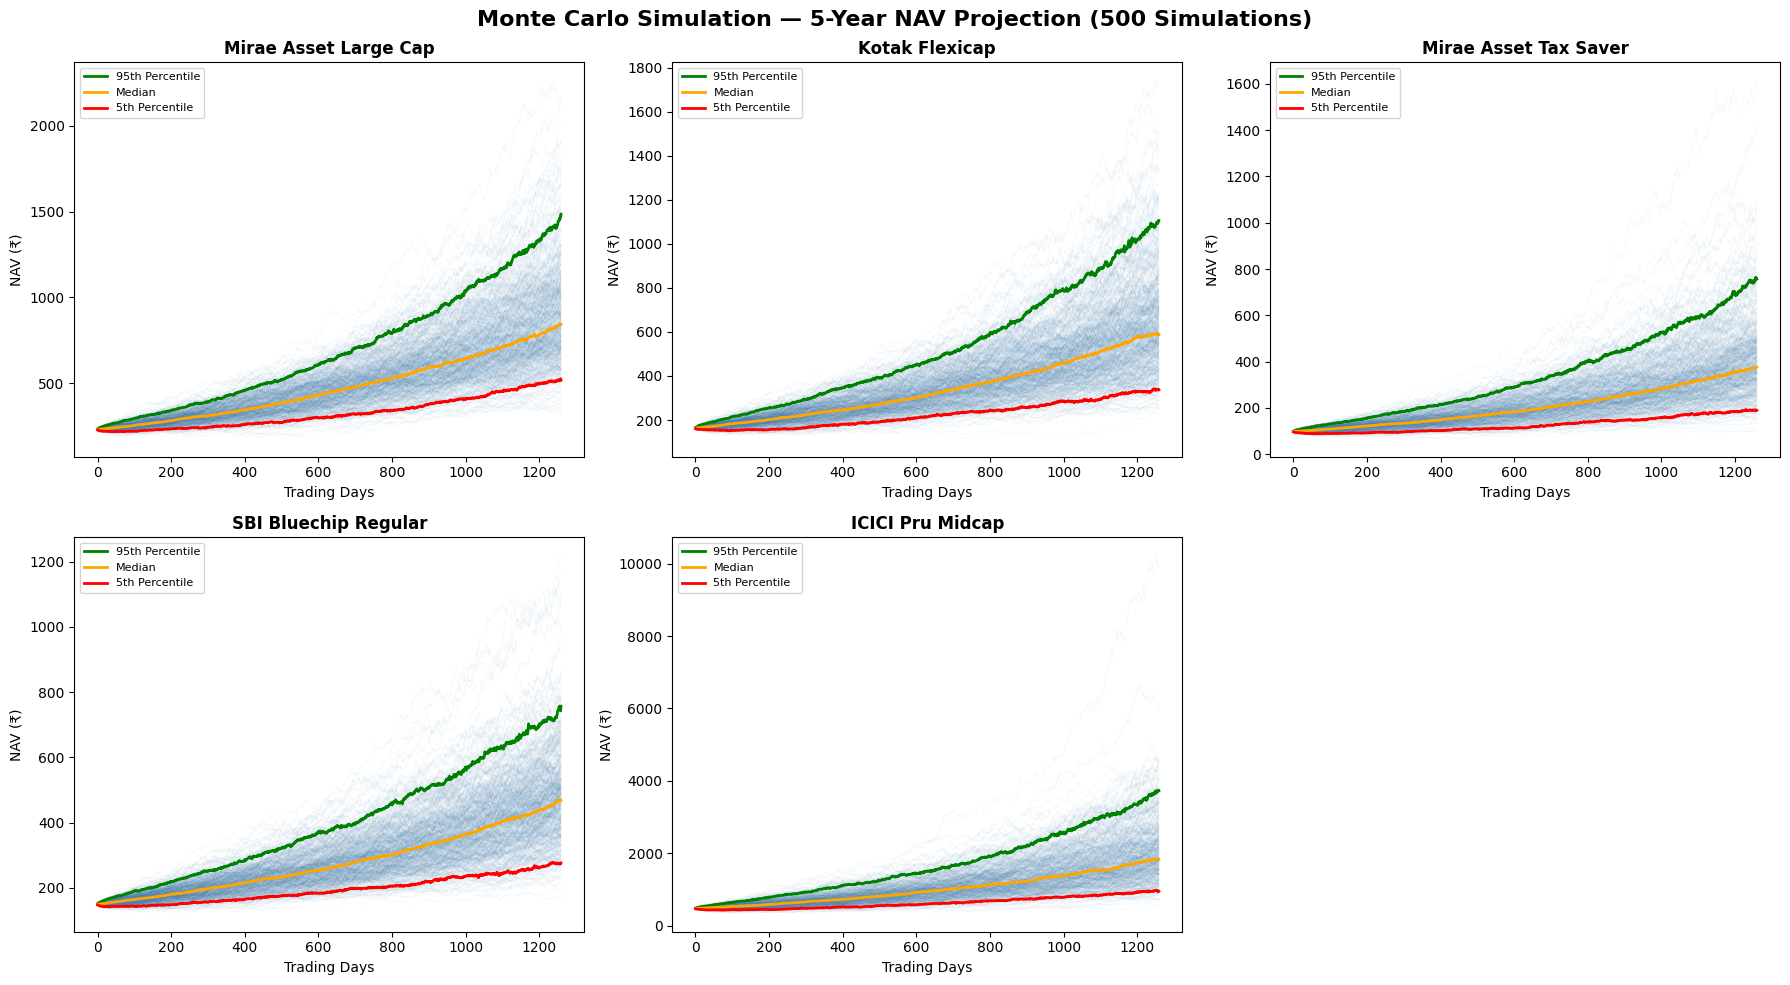

✅ Monte Carlo Simulation complete!

📊 5-Year Projection Summary:
                 fund  current_nav  median_5yr  best_case_95  worst_case_5  prob_double
Mirae Asset Large Cap       230.27      843.05       1484.50        517.64         97.2
       Kotak Flexicap       163.24      588.11       1105.75        336.99         95.8
Mirae Asset Tax Saver        97.74      376.39        756.80        189.42         94.0
 SBI Bluechip Regular       149.32      468.66        756.99        276.24         90.4
     ICICI Pru Midcap       473.76     1837.29       3728.17        950.24         95.0


In [2]:
# Cell 2 — Monte Carlo Simulation (5-year NAV projection)
import numpy as np
import matplotlib.pyplot as plt

# Select top 5 funds from scorecard
top5_codes = [148567, 120843, 148569, 119551, 120505]
top5_names = {
    148567: 'Mirae Asset Large Cap',
    120843: 'Kotak Flexicap',
    148569: 'Mirae Asset Tax Saver',
    119551: 'SBI Bluechip Regular',
    120505: 'ICICI Pru Midcap'
}

N_SIMULATIONS = 500
N_DAYS = 252 * 5  # 5 years

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
fig.suptitle('Monte Carlo Simulation — 5-Year NAV Projection (500 Simulations)', 
             fontsize=16, fontweight='bold')
axes = axes.flatten()

mc_results = []

for idx, code in enumerate(top5_codes):
    fund_returns = returns_df[returns_df['amfi_code'] == code]['daily_return']
    mu = fund_returns.mean()
    sigma = fund_returns.std()
    last_nav = nav_df[nav_df['amfi_code'] == code]['nav'].iloc[-1]
    
    simulations = np.zeros((N_DAYS, N_SIMULATIONS))
    
    for sim in range(N_SIMULATIONS):
        daily_returns = np.random.normal(mu, sigma, N_DAYS)
        price_path = [last_nav]
        for r in daily_returns:
            price_path.append(price_path[-1] * (1 + r))
        simulations[:, sim] = price_path[1:]
    
    # Plot
    ax = axes[idx]
    ax.plot(simulations, alpha=0.05, color='steelblue', linewidth=0.5)
    ax.plot(np.percentile(simulations, 95, axis=1), 
            color='green', linewidth=2, label='95th Percentile')
    ax.plot(np.percentile(simulations, 50, axis=1), 
            color='orange', linewidth=2, label='Median')
    ax.plot(np.percentile(simulations, 5, axis=1), 
            color='red', linewidth=2, label='5th Percentile')
    ax.set_title(top5_names[code], fontweight='bold')
    ax.set_xlabel('Trading Days')
    ax.set_ylabel('NAV (₹)')
    ax.legend(fontsize=8)
    
    # Store results
    final_navs = simulations[-1, :]
    mc_results.append({
        'fund': top5_names[code],
        'current_nav': round(last_nav, 2),
        'median_5yr': round(np.percentile(final_navs, 50), 2),
        'best_case_95': round(np.percentile(final_navs, 95), 2),
        'worst_case_5': round(np.percentile(final_navs, 5), 2),
        'prob_double': round((final_navs >= last_nav * 2).mean() * 100, 1)
    })

# Hide last empty subplot
axes[5].set_visible(False)

plt.tight_layout()
plt.savefig('charts/monte_carlo.png', dpi=150, bbox_inches='tight')
plt.show()

mc_df = pd.DataFrame(mc_results)
print("✅ Monte Carlo Simulation complete!")
print("\n📊 5-Year Projection Summary:")
print(mc_df.to_string(index=False))